In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms, datasets
from torchinfo import summary
from torch.utils.data import DataLoader, Subset

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [3]:
device

'mps'

In [4]:
IMG_SIZE = 224
seed = 42

In [5]:
def to_rgb(img):
    return img.convert("RGB")

In [6]:
train_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.RandomResizedCrop(IMG_SIZE, scale = (0.6,1), ratio = (0.75,1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue = 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), #imagenet standard values
    #transforms.RandomErasing(p=0.25, scale = (0.02, 0.15), ratio =(0.3, 3.3), value = "random")
])

In [7]:
test_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
from torch.utils.data import random_split
root = "../data"
test_ratio = 0.2



In [9]:
ds_train_full = datasets.Caltech101(root =root, download = True, transform = train_tf) 
ds_test_full = datasets.Caltech101(root =root, download = True, transform = test_tf) 

In [10]:
n_total = len(ds_train_full)

In [11]:
n_total

8677

In [12]:
n_test = int(n_total * test_ratio)

In [13]:
n_total, n_test

(8677, 1735)

In [14]:
n_train = n_total - n_test

In [15]:
n_total, n_test, n_train

(8677, 1735, 6942)

In [16]:
g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_total,generator = g).tolist()

In [17]:
train_idx = perm[:n_train]
test_idx = perm[n_train:]

In [18]:
len(train_idx), len(test_idx)

(6942, 1735)

In [19]:
train_ds = Subset(ds_train_full, train_idx)
test_ds = Subset(ds_test_full, test_idx)

In [20]:
len(train_ds), len(test_ds)

(6942, 1735)

In [21]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle=False)

In [22]:
img, label = ds_train_full[1000]

In [23]:
print(label)
print(ds_train_full.categories[label])

2
Leopards


In [24]:
height = 224
width = 224
color_channels = 3
patch_size = 16

number_of_patches = int((height * width) / (patch_size ** 2))

In [25]:
number_of_patches

196

In [26]:
embedding_layer_input_shape = (height, width, color_channels)
embedding_layer_output_shape = (number_of_patches, patch_size ** 2 * color_channels)

In [27]:
print(embedding_layer_input_shape)
print(embedding_layer_output_shape)

(224, 224, 3)
(196, 768)


In [28]:
224*224*3

150528

In [29]:
196*768

150528

In [30]:
image, label = train_dataloader.dataset[4]

In [31]:
class_names = ds_train_full.categories

In [32]:
class_names[label]

'helicopter'

In [33]:
image

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0822659].


Text(0.5, 1.0, 'helicopter')

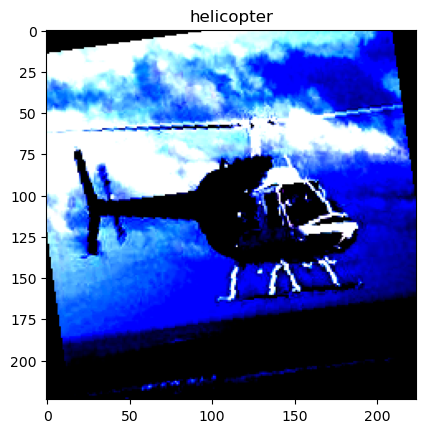

In [34]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0474076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0474076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.06

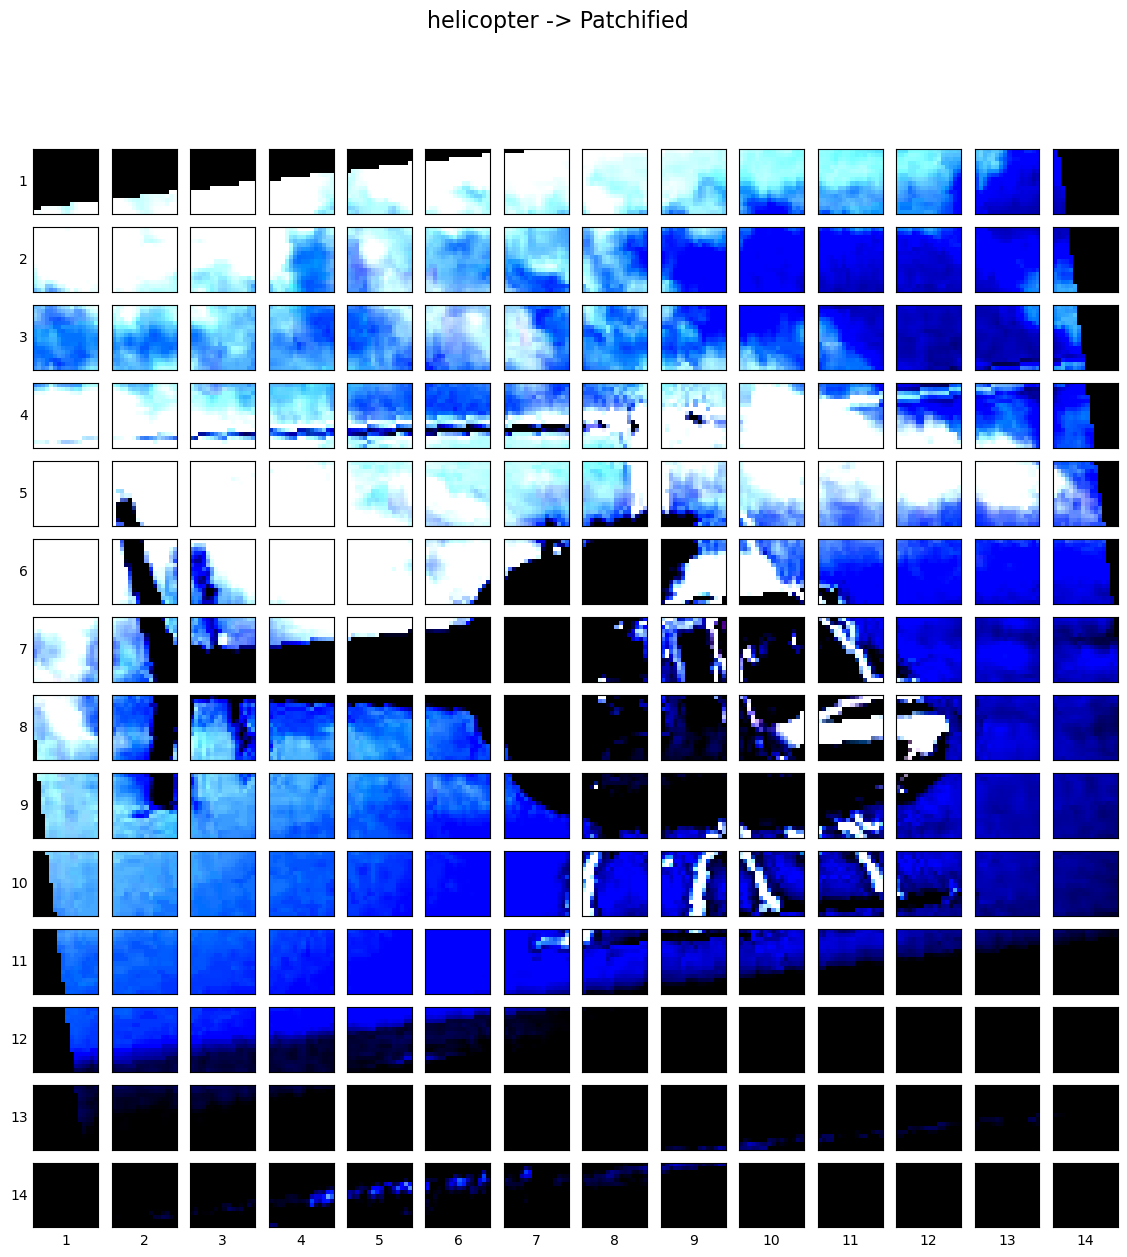

In [35]:
image_permuted = image.permute(1, 2, 0)
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [36]:
patch_size = 16
conv2d = nn.Conv2d(in_channels=3,
                  out_channels = 768,
                  kernel_size = patch_size,
                  stride = patch_size,
                  padding = 0)

In [37]:
image_out_of_conv = conv2d(image)

In [38]:
image_out_of_conv.shape

torch.Size([768, 14, 14])

In [39]:
flatten = nn.Flatten(start_dim=1, end_dim=2)

In [40]:
image_out_of_conv_flattened = flatten(image_out_of_conv)

In [41]:
image_out_of_conv_flattened.shape

torch.Size([768, 196])

In [42]:
image_out_of_conv = conv2d(image.unsqueeze(0))

In [43]:
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

In [44]:
flatten = nn.Flatten(start_dim=2, end_dim=3)

In [45]:
image_out_of_conv_flattened = flatten(image_out_of_conv)

In [46]:
image_out_of_conv_flattened.shape

torch.Size([1, 768, 196])

In [47]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels: int = 3, embedding_dim: int = 768, patch_size: int = 16, start_dim:int = 2, end_dim:int = 3):
        super().__init__()

        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding = 0)
        self.flatten = nn.Flatten(start_dim = start_dim, end_dim = end_dim)

    def forward(self, x):
        x = self.patcher(x)
        x = self.flatten(x)

        return x.permute(0,2,1)

In [48]:
patch_embedding = PatchEmbedding()

In [49]:
patch_embedded_image = patch_embedding(image.unsqueeze(0))

In [50]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [51]:
random_input_image = (1,3,224,224)

summary(PatchEmbedding(),
        input_size=random_input_image,
        col_names =["input_size",
                "output_size",
                "num_params",
                "trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
PatchEmbedding                           [1, 3, 224, 224]          [1, 196, 768]             --                        True
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 768, 14, 14]          590,592                   True
├─Flatten: 1-2                           [1, 768, 14, 14]          [1, 768, 196]             --                        --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [52]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [53]:
batch_size = patch_embedded_image.shape[0]

In [54]:
embedding_dimension = patch_embedded_image.shape[-1]

In [55]:
class_token = nn.Parameter(torch.ones(batch_size,1,embedding_dimension), requires_grad=True)

In [56]:
class_token.shape

torch.Size([1, 1, 768])

In [57]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image), dim=1)

In [58]:
patch_embedded_image_with_class_embedding

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.1759,  2.1948, -0.9799,  ...,  0.5489, -0.7720, -0.6302],
         [-0.0435,  0.3365, -0.9522,  ...,  0.5776, -0.7045, -1.4049],
         ...,
         [-0.4485,  1.6667, -0.9267,  ...,  0.6559, -0.7640, -0.3811],
         [-0.4379,  1.6531, -0.8627,  ...,  0.6593, -0.7153, -0.3473],
         [-0.3935,  1.6627, -0.8585,  ...,  0.7431, -0.7620, -0.3491]]],
       grad_fn=<CatBackward0>)

In [59]:
number_of_patches = int((height * width) / (patch_size ** 2))
embedding_dimension = patch_embedded_image_with_class_embedding.shape[-1]

position_embedding = nn.Parameter(torch.ones(1, number_of_patches + 1, embedding_dimension), requires_grad = True)

In [60]:
position_embedding.shape

torch.Size([1, 197, 768])

In [61]:
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding

In [62]:
patch_and_position_embedding

tensor([[[ 2.0000,  2.0000,  2.0000,  ...,  2.0000,  2.0000,  2.0000],
         [ 0.8241,  3.1948,  0.0201,  ...,  1.5489,  0.2280,  0.3698],
         [ 0.9565,  1.3365,  0.0478,  ...,  1.5776,  0.2955, -0.4049],
         ...,
         [ 0.5515,  2.6667,  0.0733,  ...,  1.6559,  0.2360,  0.6189],
         [ 0.5621,  2.6531,  0.1373,  ...,  1.6593,  0.2847,  0.6527],
         [ 0.6065,  2.6627,  0.1415,  ...,  1.7431,  0.2380,  0.6509]]],
       grad_fn=<AddBackward0>)

In [63]:
patch_size = 16
height, width = image.shape[1], image.shape[2]

x = image.unsqueeze(0)
print(f"input shape{x.shape}")

patch_embedding_layer = PatchEmbedding(in_channels = 3, patch_size = patch_size, embedding_dim=768)

patch_embedding = patch_embedding_layer(x)

print(f"patch embedded shape: {patch_embedding.shape}")

batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.randn(batch_size,1,embedding_dimension), requires_grad=True)

print("class token shape: ", class_token.shape) 

patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)

print(f"patch embedding class token size: {patch_embedding_class_token.shape}")

number_of_patches = int((height * width) / (patch_size ** 2))
embedding_dimension = patch_embedding_class_token.shape[-1]

position_embedding = nn.Parameter(torch.randn(1, number_of_patches + 1, embedding_dimension), requires_grad = True)

print(f"position embedding shape: {position_embedding.shape}")

patch_and_position_embedding = patch_embedding_class_token + position_embedding

print(f"patchified, class and position embedded image: {patch_and_position_embedding.shape}")

input shapetorch.Size([1, 3, 224, 224])
patch embedded shape: torch.Size([1, 196, 768])
class token shape:  torch.Size([1, 1, 768])
patch embedding class token size: torch.Size([1, 197, 768])
position embedding shape: torch.Size([1, 197, 768])
patchified, class and position embedded image: torch.Size([1, 197, 768])


In [64]:
class MultiheadSelfAttentionBlock(nn.Module):
    def __init__(self,
                embedding_dim: int = 768,
                num_heads: int = 12,
                attn_dropout: float = 0.0):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        self.multihead_attn = nn.MultiheadAttention(embed_dim= embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                   batch_first=True)
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(query = x,
                                            key = x,
                                            value = x,
                                            need_weights = False)

        return attn_output
        

In [65]:
multihead_self_attention_block = MultiheadSelfAttentionBlock()

In [66]:
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"patch_and_position_embedding shape: {patch_and_position_embedding.shape}")
print(f"patched_image_through_msa_block shape: {patched_image_through_msa_block.shape}")

patch_and_position_embedding shape: torch.Size([1, 197, 768])
patched_image_through_msa_block shape: torch.Size([1, 197, 768])


In [67]:
patched_image_through_msa_block

tensor([[[ 0.0521,  0.0012,  0.0749,  ...,  0.0136,  0.1790,  0.0560],
         [ 0.0552,  0.0375,  0.0079,  ...,  0.0886,  0.3218,  0.0014],
         [-0.0200,  0.0085,  0.0018,  ...,  0.0171,  0.2254,  0.0903],
         ...,
         [-0.0990, -0.0545, -0.0177,  ...,  0.0571,  0.1646,  0.1012],
         [ 0.0105, -0.0090, -0.0056,  ...,  0.0440,  0.2004,  0.0786],
         [ 0.0042, -0.0115,  0.0379,  ...,  0.0538,  0.2349,  0.0531]]],
       grad_fn=<TransposeBackward0>)

In [68]:
patch_and_position_embedding

tensor([[[ 0.1567,  1.4454, -0.1801,  ..., -1.2670, -0.2283,  0.0107],
         [ 0.4634,  1.9907,  0.4761,  ..., -1.0275,  3.3461,  0.4412],
         [-1.3030,  1.1600, -0.8770,  ..., -0.4329,  1.2802, -0.8129],
         ...,
         [ 0.0182,  0.7883, -0.3044,  ...,  0.2606,  0.6959, -0.3075],
         [-2.6418,  0.8118, -1.1530,  ..., -0.3974, -2.0525,  0.5054],
         [-0.3303,  1.7499, -2.1813,  ...,  0.6424,  0.9581,  0.5470]]],
       grad_fn=<AddBackward0>)

In [69]:
class MLPBlock(nn.Module):
    def __init__(self,
                embedding_dim: int = 768,
                mlp_size: int = 3072,
                dropout: float = 0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(in_features = embedding_dim, out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, out_features=embedding_dim),
            nn.Dropout(p=dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)

        return x
        

In [70]:
mlp_block = MLPBlock()

In [71]:
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print("patched_image_through_msa_block shape: ",patched_image_through_msa_block.shape)
print("patched_image_through_mlp_block shape: ",patched_image_through_mlp_block.shape)

patched_image_through_msa_block shape:  torch.Size([1, 197, 768])
patched_image_through_mlp_block shape:  torch.Size([1, 197, 768])


In [72]:
patched_image_through_msa_block

tensor([[[ 0.0521,  0.0012,  0.0749,  ...,  0.0136,  0.1790,  0.0560],
         [ 0.0552,  0.0375,  0.0079,  ...,  0.0886,  0.3218,  0.0014],
         [-0.0200,  0.0085,  0.0018,  ...,  0.0171,  0.2254,  0.0903],
         ...,
         [-0.0990, -0.0545, -0.0177,  ...,  0.0571,  0.1646,  0.1012],
         [ 0.0105, -0.0090, -0.0056,  ...,  0.0440,  0.2004,  0.0786],
         [ 0.0042, -0.0115,  0.0379,  ...,  0.0538,  0.2349,  0.0531]]],
       grad_fn=<TransposeBackward0>)

In [73]:
patched_image_through_mlp_block

tensor([[[ 0.5162, -0.5399,  0.0000,  ...,  0.0000,  0.1412, -0.1604],
         [ 0.4458, -0.5713, -0.3055,  ...,  0.0576,  0.3155, -0.1029],
         [ 0.2397, -0.4920, -0.2009,  ...,  0.0434,  0.2987, -0.0737],
         ...,
         [ 0.3965, -0.4967, -0.1869,  ...,  0.0370,  0.3126, -0.0401],
         [ 0.0822, -0.4731, -0.2410,  ...,  0.0621,  0.2627, -0.0000],
         [ 0.1976, -0.3787, -0.2547,  ..., -0.0036,  0.1742, -0.2962]]],
       grad_fn=<MulBackward0>)

In [78]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self,
                embedding_dim: int = 768,
                num_heads: int = 12,
                attn_dropout: float = 0.0,
                mlp_size: int = 3072,
                mlp_dropout: float = 0.1):
        super().__init__()
        self.msa_block = MultiheadSelfAttentionBlock(embedding_dim=embedding_dim, num_heads = num_heads, attn_dropout = attn_dropout)
        self.mlp_block = MLPBlock(embedding_dim = embedding_dim, mlp_size = mlp_size, dropout = mlp_dropout)

    def forward(self,x):
        x = self.msa_block(x) + x
        x = self.mlp_block(x) + x

        return x
        

In [79]:
transformer_encoder_block = TransformerEncoderBlock()

In [80]:
summary(model = transformer_encoder_block,
        input_size=(1,197,768),
        col_names =["input_size",
                "output_size",
                "num_params",
                "trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
TransformerEncoderBlock                  [1, 197, 768]             [1, 197, 768]             --                        True
├─MultiheadSelfAttentionBlock: 1-1       [1, 197, 768]             [1, 197, 768]             --                        True
│    └─LayerNorm: 2-1                    [1, 197, 768]             [1, 197, 768]             1,536                     True
│    └─MultiheadAttention: 2-2           --                        [1, 197, 768]             2,362,368                 True
├─MLPBlock: 1-2                          [1, 197, 768]             [1, 197, 768]             --                        True
│    └─LayerNorm: 2-3                    [1, 197, 768]             [1, 197, 768]             1,536                     True
│    └─Sequential: 2-4                   [1, 197, 768]             [1, 197, 768]             --                        True
│  

In [81]:
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model = 768,nhead=12,dim_feedforward=3072,dropout=0.1,activation="gelu",batch_first = True, norm_first = True)

In [82]:
summary(model = torch_transformer_encoder_layer,
        input_size=(1,197,768),
        col_names =["input_size",
                "output_size",
                "num_params",
                "trainable",])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
TransformerEncoderLayer                  [1, 197, 768]             [1, 197, 768]             --                        True
├─LayerNorm: 1-1                         [1, 197, 768]             [1, 197, 768]             1,536                     True
├─MultiheadAttention: 1-2                [1, 197, 768]             [1, 197, 768]             2,362,368                 True
├─Dropout: 1-3                           [1, 197, 768]             [1, 197, 768]             --                        --
├─LayerNorm: 1-4                         [1, 197, 768]             [1, 197, 768]             1,536                     True
├─Linear: 1-5                            [1, 197, 768]             [1, 197, 3072]            2,362,368                 True
├─Dropout: 1-6                           [1, 197, 3072]            [1, 197, 3072]            --                        --
├─Linea

In [88]:
class Vit(nn.Module):
    def __init__(self,
                patch_size: int = 16,
                img_size: int = 224,
                in_channels: int = 3,
                num_transformer_layer: int = 12,
                embedding_dim: int = 768,
                num_heads: int = 12,
                attn_dropout: float = 0.0,
                mlp_size: int = 3072,
                mlp_dropout: float = 0.1,
                num_classes:int = 101):
        super().__init__()

        self.num_patches = int((img_size ** 2) / (patch_size ** 2))

        self.class_embedding = nn.Parameter(torch.randn(1,1,embedding_dim),requires_grad=True)

        self.position_embedding = nn.Parameter(torch.randn(1,self.num_patches + 1, embedding_dim),requires_grad = True)

        self.patch_embedding = PatchEmbedding(in_channels = in_channels, patch_size= patch_size, embedding_dim=embedding_dim)

        self.transformer_encoder = nn.Sequential( * [TransformerEncoderBlock(embedding_dim=embedding_dim, num_heads=num_heads, attn_dropout=attn_dropout,
                                                          mlp_size = mlp_size, mlp_dropout=mlp_dropout) for _ in range(num_transformer_layer)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
            
        )

    def forward(self, x):

        batch_size = x.shape[0]

        class_token = self.class_embedding.expand(batch_size, -1,-1)
        x = self.patch_embedding(x)
        x = torch.cat((class_token,x), dim = 1)
        x = self.position_embedding + x
        x = self.transformer_encoder(x)
        x = self.classifier(x[:,0])

        return x
        

In [86]:
batch_size = 32
class_token_embedding_single = nn.Parameter(data = torch.randn(1,1,768))
class_token_embedding_batch = nn.Parameter(data = torch.randn(batch_size,1,768))

class_token_embedding_single_expand = class_token_embedding_single.expand(batch_size, -1,-1)

print(f"single class token shape: {class_token_embedding_single.shape}")
print(f"batch class token shape: {class_token_embedding_batch.shape}")
print(f"batch class expand token shape: {class_token_embedding_single_expand.shape}")

single class token shape: torch.Size([1, 1, 768])
batch class token shape: torch.Size([32, 1, 768])
batch class expand token shape: torch.Size([32, 1, 768])


In [89]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [90]:
class_names

['Faces',
 'Faces_easy',
 'Leopards',
 'Motorbikes',
 'accordion',
 'airplanes',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooster',
 'saxophone',
 'sc

In [92]:
vit = Vit(num_classes=len(class_names)).to(device)

optimizer = torch.optim.Adam(params = vit.parameters(), lr= 3e-3,weight_decay = 0.3)
loss_fn = torch.nn.CrossEntropyLoss()

In [95]:
#results = train(model = vit, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer = optimizer, loss_fn = loss_fn, device = device, epochs = 10)

In [96]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

In [97]:
pretrained_vit_weights

ViT_B_16_Weights.IMAGENET1K_V1

In [98]:
pretrained_vit = torchvision.models.vit_b_16(weights = pretrained_vit_weights).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/hasanfarukaktas/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|████████████████████████████████████████| 330M/330M [00:06<00:00, 49.9MB/s]


In [99]:
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

In [100]:
pretrained_vit.heads = nn.Linear(in_features = 768, out_features = len(class_names)).to(device)

In [102]:
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [103]:
optimizer = torch.optim.Adam(params = pretrained_vit.parameters(), lr= 3e-3,weight_decay = 0.3)
loss_fn = torch.nn.CrossEntropyLoss()

pretrained_vit_results = train(model = pretrained_vit, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer = optimizer, loss_fn = loss_fn, device = device, epochs = 5)

Epoch: 1 | train_loss: 1.9673 | train_acc: 0.7580 | test_loss: 1.8437 | test_acc: 0.8116
Epoch: 2 | train_loss: 1.8582 | train_acc: 0.7940 | test_loss: 1.9214 | test_acc: 0.7693
Epoch: 3 | train_loss: 1.8760 | train_acc: 0.7785 | test_loss: 1.7966 | test_acc: 0.7985
Epoch: 4 | train_loss: 1.8573 | train_acc: 0.7860 | test_loss: 1.8596 | test_acc: 0.8082
Epoch: 5 | train_loss: 1.8714 | train_acc: 0.7848 | test_loss: 1.8350 | test_acc: 0.7997


In [104]:
thy_path = "../data/thy.jpg"

In [105]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])


    model.to(device)
    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

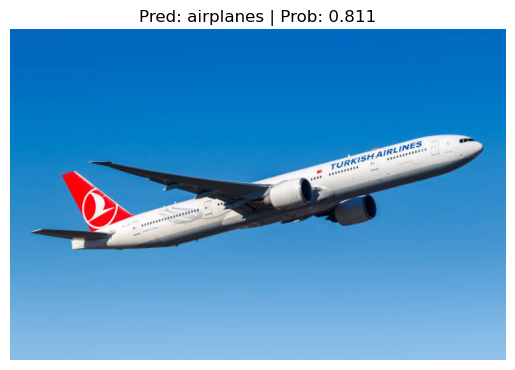

In [106]:
transform_predict(model = pretrained_vit, image_path = thy_path, class_names = class_names, device = device)